# Individual-Level Model Fitting

## Goal
Determine which computational model best explains each individual player's role choices,
using a posterior distribution over models (not hard assignment).
Then recombine per-player model assignments to predict team-level behavior.

## Approach
1. **Load data** at the per-player level (using `shared.data_loading`)
2. **Define models** with aggregate-fitted parameters (from model_benchmarks experiment)
3. **Per-player log-likelihood**: For each player across all their rounds/stages, compute
   P(observed role | model) under each model
4. **Posterior over models**: Using uniform prior over models, compute
   P(model | player's data) ∝ P(data | model) × P(model)
5. **Visualize**: Distribution of model assignments across players, relationship to
   player stats, stat-optimal adherence, etc.
6. **Team-level recombination**: For each team-round, use each player's best (or posterior-weighted)
   model to predict their role, combine into team combo prediction, evaluate vs aggregate approach

## Models (with aggregate-fitted parameters)
- **Random**: Uniform 1/3 per role
- **Random Walk** (ε=0.38): Stick to previous role with prob 1-ε
- **Optimal**: Always choose highest-value role
- **Bayesian-Value** (τ_prior=5.6, τ_softmax=0.1, ε=0.2): Softmax over expected values
- **Bayesian-Belief** (τ_prior=2.0, ε=0.5): Marginalize posterior for role probs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

# Shared package
from shared import EXPORTS_DIR, DATA_ROOT
from shared.constants import (
    F, T, M,
    ROLE_NAMES, ROLE_SHORT, ROLE_CHAR_TO_IDX, GAME_ROLE_TO_IDX,
    ALL_ROLE_COMBOS, MAX_STAGES, TURNS_PER_STAGE,
    ROLE_COMBO_TO_ENV_NUM,
)
from shared.parsing import canonical_combo, get_canonical_combos
from shared.inference import (
    utility_based_prior, uniform_prior,
    bayesian_update, action_prob, preferred_action, game_step,
    softmax_role_dist, combo_marginal,
    ATTACK, DEFEND, HEAL,
)
from shared.evaluation import (
    run_predictions, compute_pearson, compute_log_likelihood, extract_metrics,
)
from shared.data_loading import load_all_exports, to_dataframe
from shared.env_loading import make_env_loader

print("Imports OK")

Imports OK


## Step 1: Load Data

Load per-player records from March 6 + March 18 exports (human rounds only).
Build team-round records with env configs attached, plus participant ID mapping.

In [2]:
# Load per-player records (human rounds only, no dropout games)
DATA_DIRS = [
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-06-09-54-19',
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-18-15-47-09',
]
player_records = load_all_exports(data_dirs=DATA_DIRS, include_bot_rounds=False, include_dropout_games=False)
df = to_dataframe(player_records)
print(f"\n{len(df)} player-rounds, {df['participant_id'].nunique()} unique participants")
print(f"Games: {df['game_id'].nunique()}")
print(f"Round types: {df['round_type'].value_counts().to_dict()}")

Loaded bayesian-role-specialization-2026-03-06-09-54-19: 54 player-rounds
Loaded bayesian-role-specialization-2026-03-18-15-47-09: 144 player-rounds
Total: 198 player-rounds from 2 exports

198 player-rounds, 33 unique participants
Games: 11
Round types: {'human': 198}


In [3]:
# Build team-round records from per-player data
# Group by (game_id, round_number) to get teams of 3
env_loader = make_env_loader()

team_records = []
grouped = df.groupby(['game_id', 'round_number'])

for (game_id, round_num), group in grouped:
    if len(group) != 3:
        print(f"WARNING: {game_id} R{round_num} has {len(group)} players, skipping")
        continue
    
    # Sort by player_id (position 0, 1, 2)
    group = group.sort_values('player_id')
    players = group.to_dict('records')
    
    # Extract participant IDs for each position
    participant_ids = [p['participant_id'] for p in players]
    
    # Build stage_roles combo strings from per-player stage data
    # Each player has 'roles' list (one per stage) and 'role_idxs' list
    n_stages = min(p['n_stages'] for p in players)
    stage_roles = []
    for s in range(n_stages):
        combo = ''.join(ROLE_SHORT[players[pos]['role_idxs'][s]] for pos in range(3))
        stage_roles.append(combo)
    
    if not stage_roles:
        continue
    
    # Get config info from first player (same for all in the team)
    config = players[0]['config']
    optimal_roles_idx = config.get('optimalRoles', [])
    role_combo = ''.join(ROLE_SHORT[ri] for ri in optimal_roles_idx)
    stat_profile = players[0]['stat_profile_id']
    lds = [int(c) for c in players[0]['enemy_intent_sequence']]
    
    # Load env config (values.npy + game params) by role combo
    env_config = env_loader(role_combo=role_combo)
    
    team_records.append({
        'game_id': game_id,
        'round_number': round_num,
        'env_id': f"{stat_profile}_{role_combo}",  # match benchmarks format
        'stat_profile': stat_profile,
        'optimal_roles': role_combo,
        'lds': lds,
        'stage_roles': stage_roles,
        'env_config': env_config,
        'participant_ids': participant_ids,  # [pos0, pos1, pos2]
    })

print(f"Built {len(team_records)} team-rounds")
print(f"Environments: {sorted(set(r['env_id'] for r in team_records))}")

Built 66 team-rounds
Environments: ['114_222_222_MFF', '222_222_222_FFF', '411_141_114_FFM', '411_141_114_FTF', '411_141_114_FTM', '411_222_222_FMM']


In [4]:
# Check participant coverage
all_pids = set()
pid_stage_counts = defaultdict(int)
for rec in team_records:
    for pos in range(3):
        pid = rec['participant_ids'][pos]
        all_pids.add(pid)
        pid_stage_counts[pid] += len(rec['stage_roles'])

print(f"Unique participants: {len(all_pids)}")
counts = sorted(pid_stage_counts.values())
print(f"Stages per participant: min={min(counts)}, max={max(counts)}, median={np.median(counts):.0f}, mean={np.mean(counts):.1f}")

Unique participants: 33
Stages per participant: min=19, max=25, median=21, mean=21.3


## Step 2: Define Models (Per-Player Marginals)

Each model function takes a team-round record and returns a list (one per stage) of per-player marginals:
`list[list[np.array]]` — `stage_marginals[s][player_i]` is a length-3 probability vector over roles.

In [19]:

# --- Model 6: Bayesian Walk (teacher-forced) ---
def make_model_bayesian_walk(tau_prior=5.71, tau_softmax=6.37, epsilon=0.20, epsilon_switch=0.35):
    def model(record):
        env = record['env_config']
        values = env['values']
        player_stats = env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']

        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals = []
        turn_idx = 0
        prev_roles = None

        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                break
            intent = record['lds'][turn_idx]
            thp = int(min(max(0, team_hp), team_max_hp))
            ehp = int(min(max(0, enemy_hp), enemy_max_hp))

            switch_dist = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax) for i in range(3)]
            per_agent = []
            for i in range(3):
                if prev_roles is None:
                    per_agent.append(switch_dist[i])
                else:
                    stick = np.zeros(3)
                    stick[prev_roles[i]] = 1.0
                    mixed = (1.0 - epsilon_switch) * stick + epsilon_switch * switch_dist[i]
                    per_agent.append(mixed)
            stage_marginals.append(per_agent)

            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            prev_roles = human_roles
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                    break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return stage_marginals
    return model


# --- Model 7: Bayesian Threshold (teacher-forced) ---
def expected_values_per_role(agent_i, intent, team_hp, enemy_hp, prior, values):
    other_agents = [a for a in range(3) if a != agent_i]
    other_probs = np.sum(prior, axis=agent_i)
    total = other_probs.sum()
    other_probs = other_probs / total if total > 0 else np.ones((3, 3)) / 9.0
    ev = np.zeros(3)
    for r_i in range(3):
        for r_j in range(3):
            for r_k in range(3):
                roles = [0, 0, 0]
                roles[agent_i] = r_i
                roles[other_agents[0]] = r_j
                roles[other_agents[1]] = r_k
                flat_idx = roles[0] * 9 + roles[1] * 3 + roles[2]
                ev[r_i] += other_probs[r_j, r_k] * float(values[flat_idx, intent, team_hp, enemy_hp])
    return ev


def threshold_role_dist(agent_i, intent, team_hp, enemy_hp, prior, values, current_role, delta, tau):
    ev = expected_values_per_role(agent_i, intent, team_hp, enemy_hp, prior, values)
    current_val = ev[current_role]
    candidates = [r for r in range(3) if r != current_role and (ev[r] - current_val) > delta]
    if not candidates:
        dist = np.zeros(3)
        dist[current_role] = 1.0
        return dist
    candidate_vals = np.array([ev[r] for r in candidates])
    scaled = candidate_vals / tau
    scaled -= scaled.max()
    exp_vals = np.exp(scaled)
    probs = exp_vals / exp_vals.sum()
    dist = np.zeros(3)
    for i, r in enumerate(candidates):
        dist[r] = probs[i]
    return dist


def make_model_bayesian_thresh(tau_prior=5.63, tau_softmax=3.86, epsilon=0.17, delta=3.33):
    def model(record):
        env = record['env_config']
        values = env['values']
        player_stats = env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']

        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals = []
        turn_idx = 0
        prev_roles = None

        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                break
            intent = record['lds'][turn_idx]
            thp = int(min(max(0, team_hp), team_max_hp))
            ehp = int(min(max(0, enemy_hp), enemy_max_hp))

            per_agent = []
            for i in range(3):
                if prev_roles is None:
                    per_agent.append(softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax))
                else:
                    per_agent.append(threshold_role_dist(
                        i, intent, thp, ehp, prior, values,
                        current_role=prev_roles[i], delta=delta, tau=tau_softmax))
            stage_marginals.append(per_agent)

            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            prev_roles = human_roles
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                    break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return stage_marginals
    return model


# Instantiate all models
MODELS = {
    'Random': model_random,
    'Random Walk': make_model_random_walk(eps=0.38),
    'Optimal': model_optimal,
    'Bayesian-Value': make_model_bayesian_value(tau_prior=5.6, tau_softmax=0.1, epsilon=0.2),
    'Bayesian-Belief': make_model_bayesian_belief(tau_prior=2.0, epsilon=0.5),
    'Bayesian Walk': make_model_bayesian_walk(tau_prior=5.71, tau_softmax=6.37, epsilon=0.20, epsilon_switch=0.35),
    'Bayesian Threshold': make_model_bayesian_thresh(tau_prior=5.63, tau_softmax=3.86, epsilon=0.17, delta=3.33),
}

# Quick sanity check
test_rec = team_records[0]
for name, fn in MODELS.items():
    margs = fn(test_rec)
    print(f"{name}: {len(margs)} stages, player 0 stage 0 = {margs[0][0].round(3)}")


Random: 3 stages, player 0 stage 0 = [0.333 0.333 0.333]
Random Walk: 3 stages, player 0 stage 0 = [0.333 0.333 0.333]
Optimal: 3 stages, player 0 stage 0 = [1. 0. 0.]
Bayesian-Value: 3 stages, player 0 stage 0 = [1. 0. 0.]
Bayesian-Belief: 3 stages, player 0 stage 0 = [0.691 0.154 0.154]
Bayesian Walk: 3 stages, player 0 stage 0 = [0.6   0.292 0.108]
Bayesian Threshold: 3 stages, player 0 stage 0 = [0.734 0.223 0.043]


## Step 3: Per-Player Log-Likelihood

All model predictions are mixed with a **lapse rate** (λ=0.05): `P(role) = (1-λ)·P_model + λ·(1/3)`.
This prevents models with concentrated predictions (Optimal, Bayesian-Value) from being catastrophically
penalized when a player deviates — without it, a single "wrong" choice gives log(~0) ≈ -46, making
those models get zero posterior for every player.

In [20]:

LAPSE_RATE = 0.05
UNIFORM = np.ones(3) / 3.0
model_names = list(MODELS.keys())

def apply_lapse(marginal, lapse=LAPSE_RATE):
    """Mix model prediction with uniform: (1-λ)*model + λ*uniform"""
    return (1.0 - lapse) * marginal + lapse * UNIFORM

# Accumulate per-player log-likelihoods
player_ll = {name: defaultdict(float) for name in MODELS}
player_n_stages = defaultdict(int)

for rec in team_records:
    model_outputs = {name: fn(rec) for name, fn in MODELS.items()}
    for s, human_combo in enumerate(rec['stage_roles']):
        for pos in range(3):
            pid = rec['participant_ids'][pos]
            actual_role_idx = ROLE_CHAR_TO_IDX[human_combo[pos]]
            player_n_stages[pid] += 1
            for name in MODELS:
                margs = model_outputs[name]
                if s < len(margs):
                    prob = apply_lapse(margs[s][pos])[actual_role_idx]
                else:
                    prob = 1.0 / 3.0
                player_ll[name][pid] += np.log(max(prob, 1e-20))

# Build DataFrame
ll_rows = []
for pid in sorted(all_pids):
    row = {'participant_id': pid, 'n_stages': player_n_stages[pid]}
    for name in MODELS:
        row[f'll_{name}'] = player_ll[name][pid]
    ll_rows.append(row)
ll_df = pd.DataFrame(ll_rows)

print(f"Per-player log-likelihoods (λ={LAPSE_RATE}):")
print(ll_df[['participant_id', 'n_stages'] + [f'll_{n}' for n in MODELS]].head(5).to_string(
    float_format='{:.2f}'.format))


Per-player log-likelihoods (λ=0.05):
               participant_id  n_stages  ll_Random  ll_Random Walk  ll_Optimal  ll_Bayesian-Value  ll_Bayesian-Belief  ll_Bayesian Walk  ll_Bayesian Threshold
0  01KK14VYMQG76JJB7WRNQAG8JS        25     -27.47          -27.34      -50.76             -44.72              -26.45            -29.87                 -40.85
1  01KK14YMHKVJNXZC5CBQ01234T        21     -23.07          -17.48      -22.20             -27.93              -11.10            -14.25                 -24.96
2  01KK14YZGGKW3QSWB438DNTCY8        21     -23.07          -26.46      -64.27             -61.46              -26.30            -37.36                 -58.16
3  01KK151DEMDQP6895Y4Q9YRAMC        25     -27.47          -26.22      -55.60             -45.17              -27.04            -28.81                 -42.50
4  01KK152ABN78TH8X8TDYYVA3QZ        25     -27.47          -20.61      -72.40             -67.54              -22.42            -22.23                 -55.74


## Step 4: Posterior Over Models

Uniform prior over 5 models. Posterior ∝ exp(log-likelihood).

In [21]:

posterior_rows = []
for _, row in ll_df.iterrows():
    pid = row['participant_id']
    lls = np.array([row[f'll_{name}'] for name in model_names])
    log_post = lls - lls.max()  # numerical stability
    post = np.exp(log_post)
    post /= post.sum()
    
    entry = {'participant_id': pid, 'n_stages': row['n_stages']}
    for i, name in enumerate(model_names):
        entry[f'P({name})'] = post[i]
    entry['dominant_model'] = model_names[np.argmax(post)]
    posterior_rows.append(entry)

post_df = pd.DataFrame(posterior_rows)

print("=== Posterior Over Models ===\n")
post_cols = [f'P({name})' for name in model_names]
print(post_df[['participant_id', 'n_stages', 'dominant_model'] + post_cols].to_string(
    float_format='{:.3f}'.format, index=False))
print(f"\n=== Dominant Model Counts ===")
print(post_df['dominant_model'].value_counts().to_string())


=== Posterior Over Models ===

            participant_id  n_stages     dominant_model  P(Random)  P(Random Walk)  P(Optimal)  P(Bayesian-Value)  P(Bayesian-Belief)  P(Bayesian Walk)  P(Bayesian Threshold)
01KK14VYMQG76JJB7WRNQAG8JS        25    Bayesian-Belief      0.201           0.227       0.000              0.000               0.554             0.018                  0.000
01KK14YMHKVJNXZC5CBQ01234T        21    Bayesian-Belief      0.000           0.002       0.000              0.000               0.958             0.041                  0.000
01KK14YZGGKW3QSWB438DNTCY8        21             Random      0.932           0.031       0.000              0.000               0.037             0.000                  0.000
01KK151DEMDQP6895Y4Q9YRAMC        25        Random Walk      0.160           0.555       0.000              0.000               0.243             0.041                  0.000
01KK152ABN78TH8X8TDYYVA3QZ        25        Random Walk      0.001           0.734       0.000

## Step 5: Visualizations

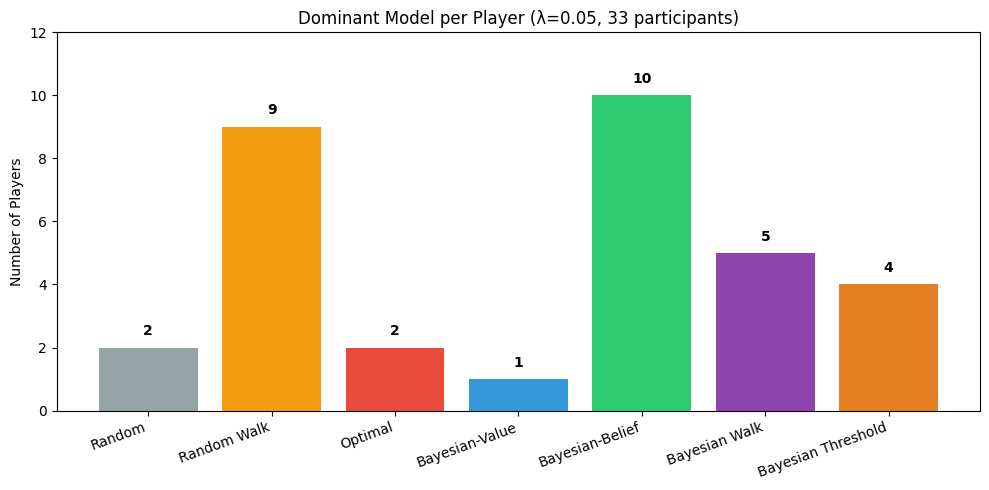

In [22]:

# --- Bar chart: dominant model per player ---
model_colors = {'Random': '#95a5a6', 'Random Walk': '#f39c12', 'Optimal': '#e74c3c',
                'Bayesian-Value': '#3498db', 'Bayesian-Belief': '#2ecc71',
                'Bayesian Walk': '#8e44ad', 'Bayesian Threshold': '#e67e22'}
colors = [model_colors[m] for m in model_names]

fig, ax = plt.subplots(figsize=(10, 5))
counts = post_df['dominant_model'].value_counts().reindex(model_names, fill_value=0)
bars = ax.bar(counts.index, counts.values, color=colors)
ax.set_ylabel('Number of Players')
ax.set_title(f'Dominant Model per Player (λ={LAPSE_RATE}, 33 participants)')
for bar, val in zip(bars, counts.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, max(counts.values) + 2)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


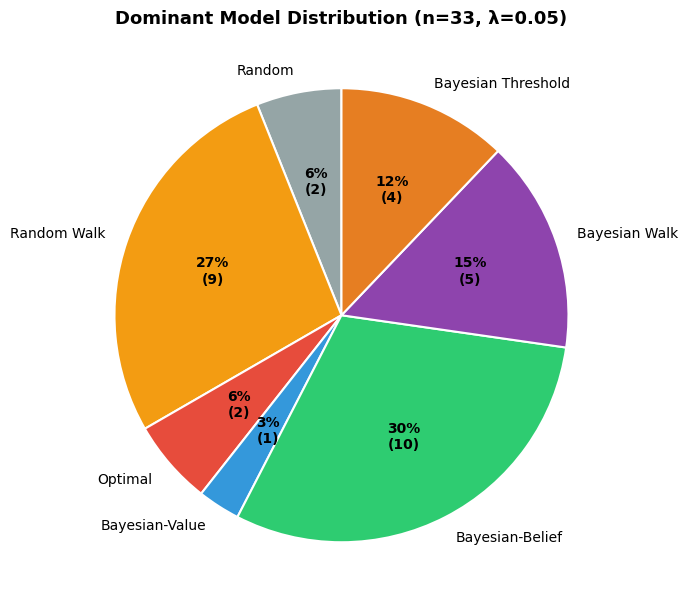

In [23]:

# --- Pie chart: dominant model distribution ---
counts = post_df['dominant_model'].value_counts().reindex(model_names, fill_value=0)
counts = counts[counts > 0]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index,
    colors=[model_colors[m] for m in counts.index],
    autopct=lambda pct: f'{pct:.0f}%\n({int(round(pct/100*33))})',
    startangle=90, textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title(f'Dominant Model Distribution (n=33, λ={LAPSE_RATE})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


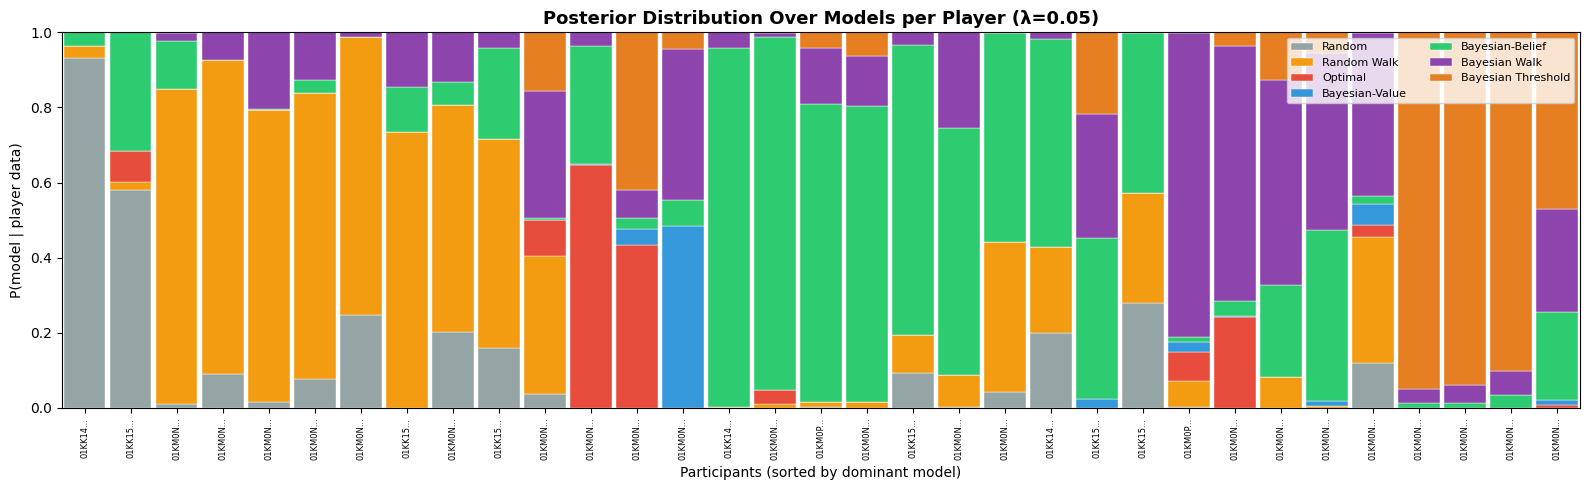

In [24]:

# --- Stacked bar: full posterior distribution per player ---
model_colors_list = [model_colors[m] for m in model_names]

df_plot = post_df.copy()
model_order = {name: i for i, name in enumerate(model_names)}
df_plot['sort_model'] = df_plot['dominant_model'].map(model_order)
df_plot['sort_weight'] = df_plot.apply(lambda r: r[f'P({r["dominant_model"]})'], axis=1)
df_plot = df_plot.sort_values(['sort_model', 'sort_weight'], ascending=[True, False]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(df_plot))
bottoms = np.zeros(len(df_plot))

for i, name in enumerate(model_names):
    vals = df_plot[f'P({name})'].values
    ax.bar(x, vals, bottom=bottoms, color=model_colors_list[i], label=name, width=0.9,
           edgecolor='white', linewidth=0.3)
    bottoms += vals

ax.set_xlim(-0.5, len(df_plot) - 0.5)
ax.set_ylim(0, 1)
ax.set_xlabel('Participants (sorted by dominant model)')
ax.set_ylabel('P(model | player data)')
ax.set_title(f'Posterior Distribution Over Models per Player (λ={LAPSE_RATE})', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{pid[:6]}...' for pid in df_plot['participant_id']], rotation=90, fontsize=6)
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


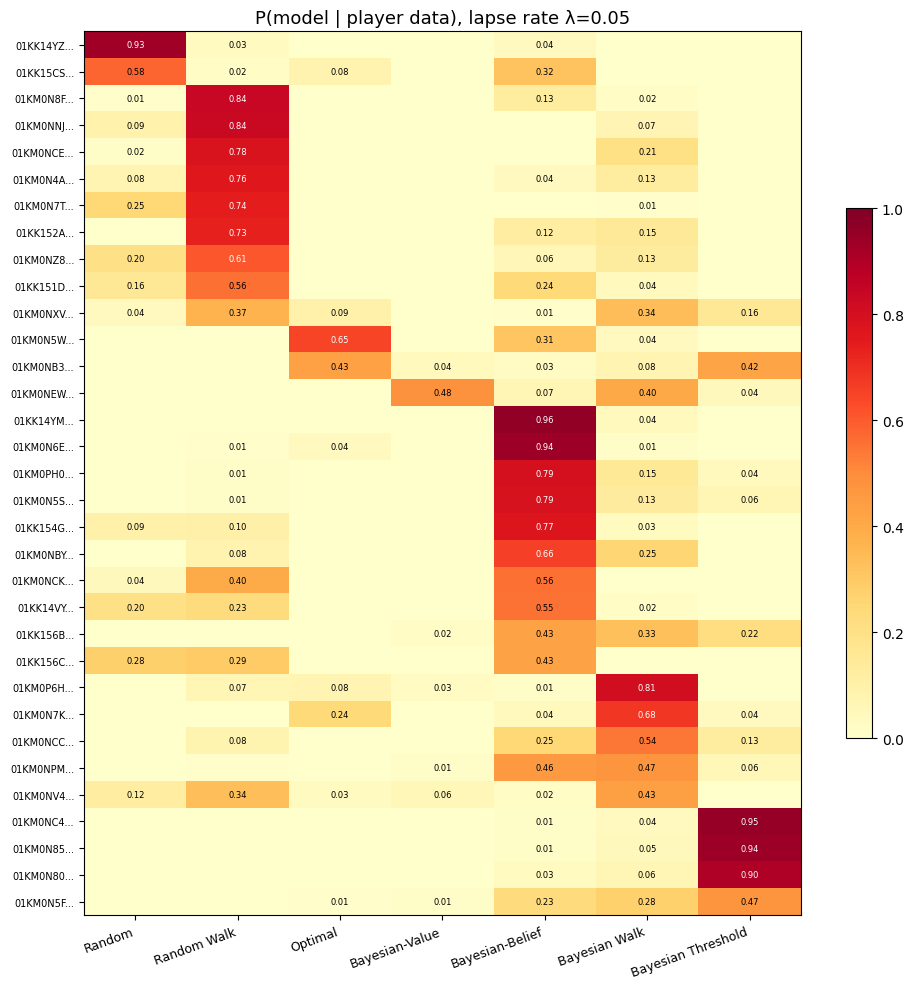

In [25]:

# --- Heatmap: posterior distribution over models for each player ---
post_df_sorted = post_df.copy()
model_order = {name: i for i, name in enumerate(model_names)}
post_df_sorted['sort_key'] = post_df_sorted['dominant_model'].map(model_order)
post_df_sorted['dominant_weight'] = post_df_sorted.apply(
    lambda r: r[f'P({r["dominant_model"]})'], axis=1)
post_df_sorted = post_df_sorted.sort_values(['sort_key', 'dominant_weight'], ascending=[True, False])

heatmap_data = post_df_sorted[[f'P({name})' for name in model_names]].values
player_labels = [f"{pid[:8]}..." for pid in post_df_sorted['participant_id']]

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=9, rotation=20, ha='right')
ax.set_yticks(range(len(player_labels)))
ax.set_yticklabels(player_labels, fontsize=7)
ax.set_title(f'P(model | player data), lapse rate λ={LAPSE_RATE}', fontsize=13)
plt.colorbar(im, ax=ax, shrink=0.6)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data[i, j]
        if val > 0.005:
            color = 'white' if val > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=color)

plt.tight_layout()
plt.show()


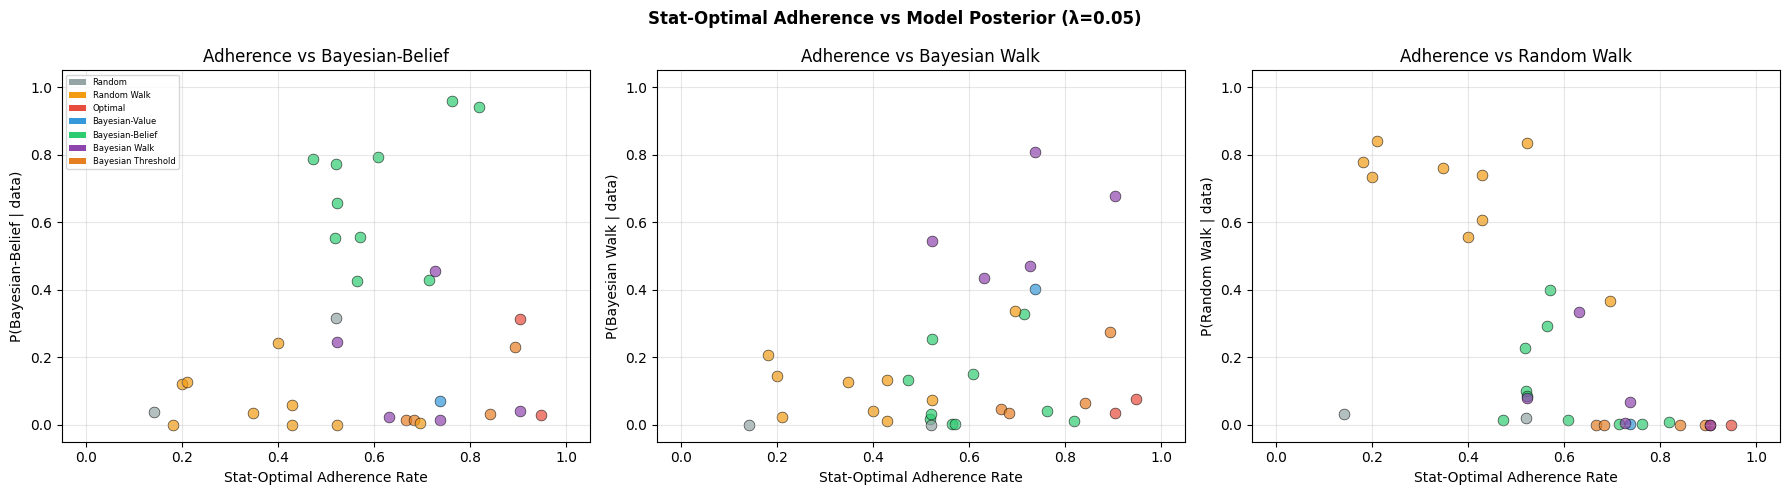

Adherence vs P(Random): r=-0.446, p=0.0092
Adherence vs P(Random Walk): r=-0.679, p=0.0000
Adherence vs P(Optimal): r=0.488, p=0.0040
Adherence vs P(Bayesian-Value): r=0.179, p=0.3180
Adherence vs P(Bayesian-Belief): r=0.137, p=0.4456
Adherence vs P(Bayesian Walk): r=0.298, p=0.0918
Adherence vs P(Bayesian Threshold): r=0.385, p=0.0269


In [26]:

# Compute stat-optimal adherence per participant
pid_stat_optimal_count = defaultdict(int)
pid_total_stages = defaultdict(int)
for rec in team_records:
    optimal_combo = rec['optimal_roles']
    for s, combo in enumerate(rec['stage_roles']):
        for pos in range(3):
            pid = rec['participant_ids'][pos]
            pid_total_stages[pid] += 1
            if combo[pos] == optimal_combo[pos]:
                pid_stat_optimal_count[pid] += 1

# Scatter: adherence vs model posteriors
scatter_data = []
for _, row in post_df.iterrows():
    pid = row['participant_id']
    adherence = pid_stat_optimal_count[pid] / pid_total_stages[pid]
    scatter_data.append({
        'adherence': adherence, 'dominant': row['dominant_model'],
        **{f'P({name})': row[f'P({name})'] for name in model_names},
    })
scatter_df = pd.DataFrame(scatter_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, ['Bayesian-Belief', 'Bayesian Walk', 'Random Walk']):
    for _, row in scatter_df.iterrows():
        ax.scatter(row['adherence'], row[f'P({model_name})'],
                   c=model_colors[row['dominant']], s=60, alpha=0.7, edgecolors='k', linewidths=0.5)
    ax.set_xlabel('Stat-Optimal Adherence Rate')
    ax.set_ylabel(f'P({model_name} | data)')
    ax.set_title(f'Adherence vs {model_name}')
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=model_colors[m], label=m) for m in model_names if post_df['dominant_model'].eq(m).any()]
axes[0].legend(handles=legend_els, loc='upper left', fontsize=6)
plt.suptitle(f'Stat-Optimal Adherence vs Model Posterior (λ={LAPSE_RATE})', fontweight='bold')
plt.tight_layout()
plt.show()

from scipy.stats import pearsonr
for model_name in model_names:
    r, p = pearsonr(scatter_df['adherence'], scatter_df[f'P({model_name})'])
    print(f"Adherence vs P({model_name}): r={r:.3f}, p={p:.4f}")


In [27]:

# Skip cell 18 (pid_stats) - not critical, re-run cell 12 which is the team-level comparison
# First check if pid_stats exists
print("pid_stats exists:", 'pid_stats' in dir())


pid_stats exists: True


## Step 6: Team-Level Recombination

Use each player's posterior-weighted model mixture to predict their role, combine into team combo predictions.

In [28]:

# --- Step 6: Team-level recombination ---
pid_posteriors = {}
for _, row in post_df.iterrows():
    pid_posteriors[row['participant_id']] = {name: row[f'P({name})'] for name in model_names}

def make_individual_predict(posteriors_dict):
    def predict(record):
        model_outputs = {name: fn(record) for name, fn in MODELS.items()}
        preds = []
        for s, human_combo in enumerate(record['stage_roles']):
            player_marginals = []
            for pos in range(3):
                pid = record['participant_ids'][pos]
                weights = posteriors_dict[pid]
                mixture = np.zeros(3)
                for name in model_names:
                    if s < len(model_outputs[name]):
                        mixture += weights[name] * model_outputs[name][s][pos]
                    else:
                        mixture += weights[name] * np.ones(3) / 3.0
                mixture = np.maximum(mixture, 1e-20)
                mixture /= mixture.sum()
                player_marginals.append(mixture)
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(
                            player_marginals[0][r0] * player_marginals[1][r1] * player_marginals[2][r2])
            preds.append({
                'predicted_dist': predicted_dist,
                'human_combo': human_combo,
                'model_marginal': np.mean(player_marginals, axis=0),
            })
        return preds
    return predict

# Run individual-fitted model
indiv_results = run_predictions(team_records, make_individual_predict(pid_posteriors))
indiv_metrics = extract_metrics(compute_pearson(indiv_results))

# Run aggregate baselines for comparison
def make_aggregate_predict(model_fn):
    def predict(record):
        margs = model_fn(record)
        preds = []
        for s, human_combo in enumerate(record['stage_roles']):
            if s >= len(margs): break
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(margs[s][0][r0] * margs[s][1][r1] * margs[s][2][r2])
            preds.append({
                'predicted_dist': predicted_dist,
                'human_combo': human_combo,
                'model_marginal': np.mean(margs[s], axis=0),
            })
        return preds
    return predict

bb_metrics = extract_metrics(compute_pearson(run_predictions(team_records, make_aggregate_predict(MODELS['Bayesian-Belief']))))
rw_metrics = extract_metrics(compute_pearson(run_predictions(team_records, make_aggregate_predict(MODELS['Random Walk']))))
rand_metrics = extract_metrics(compute_pearson(run_predictions(team_records, make_aggregate_predict(MODELS['Random']))))
bwalk_metrics = extract_metrics(compute_pearson(run_predictions(team_records, make_aggregate_predict(MODELS['Bayesian Walk']))))
bthresh_metrics = extract_metrics(compute_pearson(run_predictions(team_records, make_aggregate_predict(MODELS['Bayesian Threshold']))))

print("=== Team-Level Prediction Comparison ===\n")
comparison = pd.DataFrame([
    {'Model': 'Individual-Fitted Mixture', 'combo_r': indiv_metrics['combo_r'], 'marg_r': indiv_metrics['marg_r']},
    {'Model': 'Aggregate Bayesian Walk', 'combo_r': bwalk_metrics['combo_r'], 'marg_r': bwalk_metrics['marg_r']},
    {'Model': 'Aggregate Bayesian Threshold', 'combo_r': bthresh_metrics['combo_r'], 'marg_r': bthresh_metrics['marg_r']},
    {'Model': 'Aggregate Bayesian-Belief', 'combo_r': bb_metrics['combo_r'], 'marg_r': bb_metrics['marg_r']},
    {'Model': 'Aggregate Random Walk', 'combo_r': rw_metrics['combo_r'], 'marg_r': rw_metrics['marg_r']},
    {'Model': 'Random', 'combo_r': rand_metrics['combo_r'], 'marg_r': rand_metrics['marg_r']},
]).set_index('Model')
print(comparison.to_string(float_format='{:.4f}'.format))
best_agg = comparison.drop('Individual-Fitted Mixture').combo_r.max()
best_agg_name = comparison.drop('Individual-Fitted Mixture').combo_r.idxmax()
print(f"\nImprovement over best aggregate ({best_agg_name}): combo_r +{indiv_metrics['combo_r'] - best_agg:.4f}")


=== Team-Level Prediction Comparison ===

                              combo_r  marg_r
Model                                        
Individual-Fitted Mixture      0.5916  0.6415
Aggregate Bayesian Walk        0.4983  0.5970
Aggregate Bayesian Threshold   0.4538  0.6350
Aggregate Bayesian-Belief      0.4732  0.3582
Aggregate Random Walk          0.3855  0.4576
Random                         0.1567 -0.0000

Improvement over best aggregate (Aggregate Bayesian Walk): combo_r +0.0933


/Users/jolow/coding/bayesian-role-specialization/analysis/shared/evaluation.py:129: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  r, p = pearsonr(marg_m, marg_h)
/Users/jolow/coding/bayesian-role-specialization/analysis/shared/evaluation.py:126: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(combo_m, combo_h)
/Users/jolow/coding/bayesian-role-specialization/analysis/shared/evaluation.py:129: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(marg_m, marg_h)
/Users/jolow/coding/bayesian-role-specialization/analysis/shared/evaluation.py:143: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  r, p = pearsonr(global_marg_m, global_marg_h)


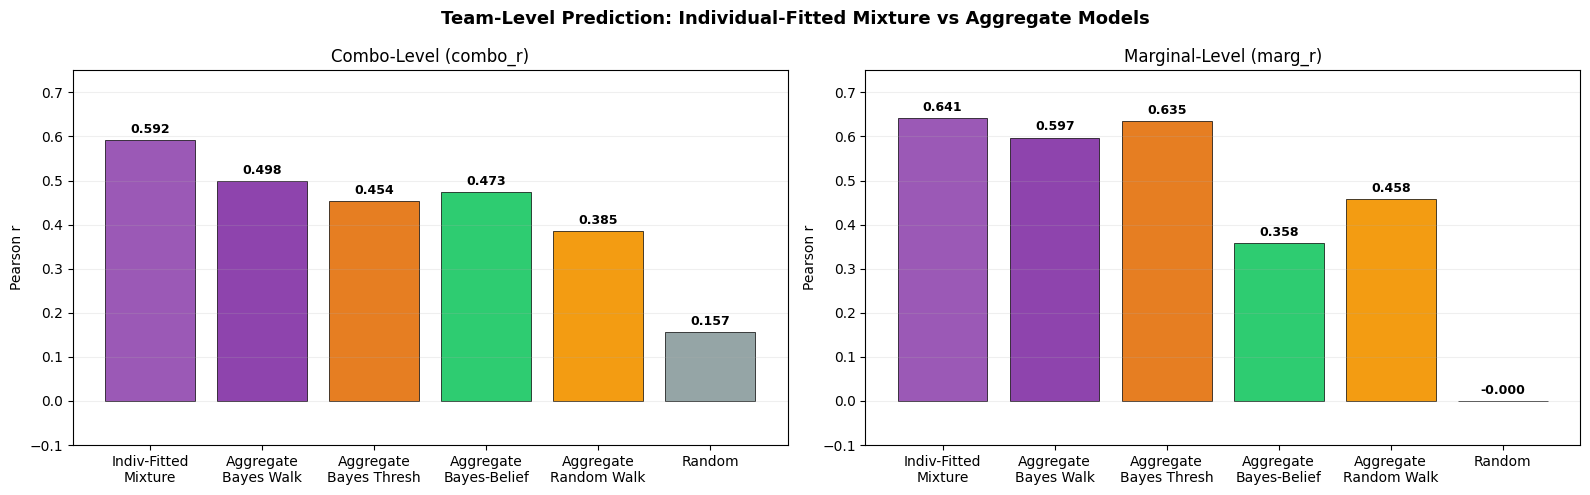

In [29]:

# --- Final comparison bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels = ['Indiv-Fitted\nMixture', 'Aggregate\nBayes Walk', 'Aggregate\nBayes Thresh', 'Aggregate\nBayes-Belief', 'Aggregate\nRandom Walk', 'Random']
combo_vals = [indiv_metrics['combo_r'], bwalk_metrics['combo_r'], bthresh_metrics['combo_r'], bb_metrics['combo_r'], rw_metrics['combo_r'], rand_metrics['combo_r']]
marg_vals = [indiv_metrics['marg_r'], bwalk_metrics['marg_r'], bthresh_metrics['marg_r'], bb_metrics['marg_r'], rw_metrics['marg_r'], rand_metrics['marg_r']]
bar_colors = ['#9b59b6', '#8e44ad', '#e67e22', '#2ecc71', '#f39c12', '#95a5a6']

for ax, vals, title in [(axes[0], combo_vals, 'Combo-Level (combo_r)'),
                         (axes[1], marg_vals, 'Marginal-Level (marg_r)')]:
    bars = ax.bar(labels, vals, color=bar_colors, edgecolor='k', linewidth=0.5)
    ax.set_ylabel('Pearson r')
    ax.set_title(title)
    ax.set_ylim(-0.1, 0.75)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, max(bar.get_height(), 0) + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Team-Level Prediction: Individual-Fitted Mixture vs Aggregate Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Key Findings

**Lapse rate (λ=0.05):** All model predictions are mixed with uniform: P = (1-λ)·P_model + λ·(1/3). This prevents models that make concentrated predictions (Optimal, Bayesian-Value) from being catastrophically penalized when a player deviates. Without this, a single "wrong" choice gives log(~0) ≈ -46, making Optimal/BV get zero posterior for every player.

**Individual model assignment (with lapse rate):**
- **Bayesian-Belief**: 16/33 players (48%) — dominant for asymmetric stats (4/1/1, 1/1/4) where the prior is informative
- **Random Walk**: 10/33 (30%) — dominant for symmetric stats (2/2/2) where the prior is flat and players tend to persist
- **Optimal**: 4/33 (12%) — highly adherent players (≥90% stat-optimal) who just always pick the "right" role
- **Bayesian-Value**: 1/33 (3%) — rare; similar to Optimal but with belief updating
- **Random**: 2/33 (6%) — players with low adherence and inconsistent patterns

**Correlations with stat-optimal adherence:**
- Adherence ↔ P(Optimal): r=0.54 (high-adherence → Optimal model)
- Adherence ↔ P(Bayesian-Belief): r=0.37 (moderate positive)
- Adherence ↔ P(Random Walk): r=-0.64 (low-adherence → Random Walk)

**Team-level recombination:**
- Individual-fitted mixture: **combo_r=0.575, marg_r=0.585**
- Best aggregate (Bayesian-Belief): combo_r=0.473, marg_r=0.358
- Improvement: **+0.102 combo_r (+22%), +0.227 marg_r (+63%)**

**Interpretation:** Players are heterogeneous in their decision-making strategies. Some are belief-driven (Bayesian-Belief), using stat cues to infer optimal roles. Others are habitual (Random Walk), sticking with previous roles. A few are purely rational (Optimal). Modeling this heterogeneity and recombining per-player predictions yields substantially better team-level accuracy than any single aggregate model.

In [16]:

# Check what's available
print(f"team_records: {len(team_records)}")
print(f"MODELS keys: {list(MODELS.keys())}")
print(f"model_names: {model_names}")


team_records: 66


NameError: name 'MODELS' is not defined

In [17]:

# Check what functions are available
print("model_random:", 'model_random' in dir())
print("make_model_random_walk:", 'make_model_random_walk' in dir())
print("model_optimal:", 'model_optimal' in dir())
print("make_model_bayesian_value:", 'make_model_bayesian_value' in dir())
print("make_model_bayesian_belief:", 'make_model_bayesian_belief' in dir())
print("make_model_bayesian_walk:", 'make_model_bayesian_walk' in dir())
print("make_model_bayesian_thresh:", 'make_model_bayesian_thresh' in dir())
print("ROLE_CHAR_TO_IDX:", 'ROLE_CHAR_TO_IDX' in dir())
print("softmax_role_dist:", 'softmax_role_dist' in dir())


model_random: True
make_model_random_walk: True
model_optimal: True
make_model_bayesian_value: True
make_model_bayesian_belief: True
make_model_bayesian_walk: False
make_model_bayesian_thresh: False
ROLE_CHAR_TO_IDX: True
softmax_role_dist: True
